In [1]:
#! /usr/bin/env python
#!!!!! This code is for the publication level

#-------------------------------------------------------------------------------
# . File      : pyKinetics.py (python3.9.13)
# . Program   : MolarisTools
# . Copyright : USC, Aoxuan(Augustine) Zhang (aoxuanzh@usc.edu, Aug 4, 2024)
# . License   : GNU GPL v3.0       (http://www.gnu.org/licenses/gpl-3.0.en.html)
#-------------------------------------------------------------------------------

help_message = """
This python script helps to do a numerical integration of a set of coupled ODEs to determine
the time evolution of different species in the solvent, it is tested for the followint kinetic model
E + I <-> EI1 <-> EI2 -> EI
in which '<->' denotes a reversible process

Time dependent IC50 of a covalent inhibitor can be calculated if the rate constant is numerically calculate
in this way, for more details please refer to the publication below, in which this code and data have been used

Testing data were from:
A Nandi, M Asadi, A Zhang, Z T Chu, A Warshel*. Mechanistic Insights into Nitrile and Alkyne Covalent Inhibitors of the SARS-CoV-2 Main Protease. ACS Catal 15, 2, 1158–1169, 2025.

"""

from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

[-6.64741408 -6.50510932 -6.39976184 -6.31777119 -6.25182922 -6.19755303
 -6.1521067  -6.1135499  -6.08049696 -6.05192426 -6.02705457 -6.0052842
 -5.9861353  -5.96922345 -5.95423512 -5.94091149 -5.92903671 -5.91842908
 -5.90893446 -5.90042112 -5.89277579 -5.88590053 -5.87971022 -5.87413057
 -5.86909645 -5.86455058 -5.86044243 -5.85672725 -5.85336535 -5.85032143
 -5.847564   -5.84506497 -5.84279918 -5.8407441  -5.8388795  -5.83718723
 -5.83565092 -5.83425585 -5.83298876 -5.83183767 -5.83079176 -5.82984126
 -5.82897735 -5.82819201 -5.82747802 -5.82682882 -5.82623847 -5.82570158
 -5.82521327 -5.82476911]


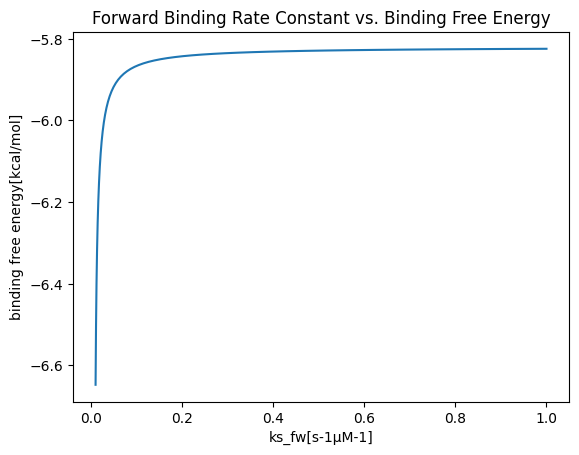

In [2]:
#--------------------------------------------------------------
#
# Pre-liminary
#
# This block is for carefully analyze substrate kinetics,
# which is Km and ks_cat are given, how ks_fw and ks_bw are related to each other,
# and hence the reasonable range of their values
# that can be applied to the following IC50 calculations
#
#--------------------------------------------------------------

# experimental data
Km = 57.3           # [uM], binding affinity of natural substrate
ks_cat = 0.43       # [s**(-1)], apparent enzymatic rate constant

# now we set the ks_fw and ks_bw dependence using Michealis-Menten formula

ks_fw_start = -2         # [(s*uM)**(-1)], forward binding rate constant, log space is used, the real start will be base**(I0_start)
ks_fw_end   = 0          # [s**(-1)], backward binding rate constant
ks_fw_list = np.logspace(ks_fw_start, ks_fw_end, 50)

ks_bw_list = Km*ks_fw_list - ks_cat
dG_bind = -0.5959*np.log(1e6*ks_fw_list/ks_bw_list)
# plt.plot (ks_fw_list, ks_bw_list)
# plt.xscale ('log')
# plt.yscale ('log')
plt.plot (ks_fw_list, dG_bind)
plt.title('Forward Binding Rate Constant vs. Binding Free Energy')
plt.xlabel('ks_fw[s-1\u03bcM-1]')
plt.ylabel('binding free energy[kcal/mol]')
print (dG_bind)

2.56962539793502
1.0092309876465777


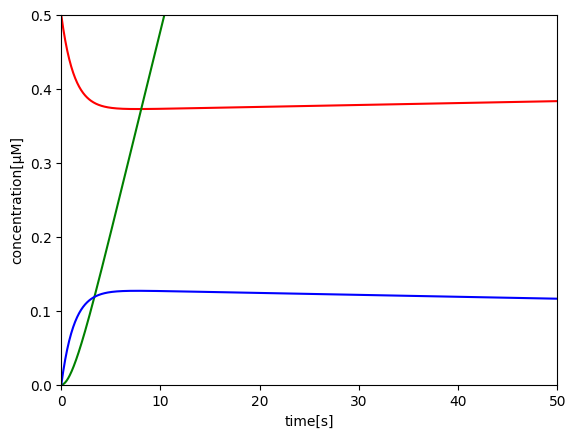

In [3]:
#------------------------------
#
#   Real code starts here
# We first get Kinetics for the natrual substrate as a reference for the following IC50 calculations
#
#------------------------------

ks_fw  = 1e-2
ks_bw  = 0.143
ks_cat = 0.43

# Define the ODEs
# ODEs for preliminary enzyme test, the result will be the reference for IC50 calculation
def odes00(x,t):
    
    # kinetic data
#     ks_fw  = 0.2
#     ks_bw  = 11.3
#     ks_cat = 0.43
    
    # assign each ODE to a vector element
    E  = x[0]  # apo enzyme, [nM] so as the following elements
    S  = x[1]  # substrate
    ES = x[2]  # substrate-enzyme complex
    P  = x[3]  # free product
    
    # define each ODE
    dEdt  = -ks_fw*E*S + (ks_bw + ks_cat)*ES
    dSdt  = -ks_fw*E*S + ks_bw*ES
    dESdt = ks_fw*E*S - (ks_bw + ks_cat)*ES
    dPdt  = ks_cat*ES
    
    return [dEdt, dSdt, dESdt, dPdt]

# Give initial conditions
x00 = [0.5, 20, 0, 0]

# Declare a time vector
t_end = 2000
step_size = 0.05
tot_step = int(t_end/step_size)
t = np.linspace(0, t_end, tot_step)
x = odeint(odes00, x00, t)
E          = x[:,0]
S          = x[:,1]
ES         = x[:,2]
P          = x[:,3]

# plot
plt.plot(t, E, color = 'red')
plt.plot(t, S, color = 'orange')
plt.plot(t, P, color = 'green')
plt.plot(t, ES, color = 'blue')
plt.xlim(0,50)
plt.ylim(0,0.5)
plt.xlabel('time[s]')
plt.ylabel('concentration[\u03bcM]')
print (P[int(50/step_size)])
vP0 = P[int(50/step_size)]             # apparent rate for the enzymatic reaction, will be used for the following IC50 calculation
ratio = (P[int(50/step_size)]/50)/(P[int(20/step_size)]/20)
print (ratio)

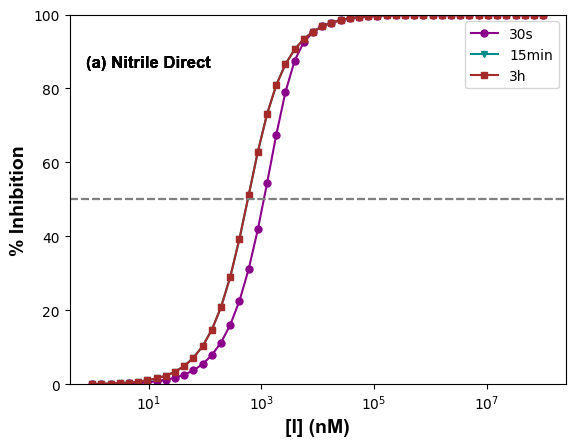

In [4]:
#---------------------------------------------------
#
#    ODE Define Block for Incubation (odes01)
#            and IC50 simulation (odes02)
#
#---------------------------------------------------


# For convenience, all rate constants are assigned out of function definition block
# But be sure to modify it if other purposes are served

k1_fw = 2e-2       # [(s*uM)**(-1)], forward reaction rate constant for the 1st elementary step
k1_bw = 1.5e-2     # [s**(-1)], backward reaction rate constant for the 1st elementary reaction
k2_fw = 3.31       # [s**(-1)], forward reaction rate constant for the 2nd elementary reaction
k2_bw = 1.97       # [s**(-1)], backward reaction rate constant for the 2nd elementary reaction
# ks_fw  = 0.2
# ks_bw  = 11.3
# ks_cat = 0.43

# Define the ODEs
# ODEs for preincubation
def odes01(x,t):
    
    # kinetic data
#     k1_fw = 1e-3
#     k1_bw = 0.034195405
#     k2_fw = 74
#     k2_bw = 7e-4
    
    # assign each ODE to a vector element
    E        = x[0]  # apo enzyme, [nM] so as the following elements
    I        = x[1]  # unbound ligand
    EInoncov = x[2]  # complex for the 1st reaction
    EIcov    = x[3]  # complex for the 2nd reaction
    
    # define each ODE
    dEdt        = -k1_fw*E*I + k1_bw*EInoncov
    dIdt        = -k1_fw*E*I + k1_bw*EInoncov
    dEInoncovdt = k1_fw*E*I - (k1_bw + k2_fw)*EInoncov + k2_bw*EIcov
    dEIcovdt    = k2_fw*EInoncov - k2_bw*EIcov
    
    return [dEdt, dIdt, dEInoncovdt, dEIcovdt]

# Define the ODEs
# ODEs for IC50 simulation at time t
def odes02(x,t):
    
    # kinetic data
#     k1_fw = 1e-3
#     k1_bw = 0.034195405
#     k2_fw = 74
#     k2_bw = 7e-4
#     ks_fw  = 1e-2
#     ks_bw  = 0.143
#     ks_cat = 0.43
    
    # assign each ODE to a vector element
    E        = x[0]  # apo enzyme, [nM] so as the following elements
    I        = x[1]  # unbound ligand
    EInoncov = x[2]  # complex for the 1st reaction
    EIcov    = x[3]  # complex for the 2nd reaction
    S        = x[4]
    ES       = x[5]
    P        = x[6]
    
    # define each ODE
    dEdt        = - k1_fw*E*I + k1_bw*EInoncov - ks_fw*E*S + ks_bw*ES + ks_cat*ES
    dIdt        = - k1_fw*E*I + k1_bw*EInoncov
    dEInoncovdt = k1_fw*E*I - (k1_bw + k2_fw)*EInoncov + k2_bw*EIcov
    dEIcovdt    = k2_fw*EInoncov - k2_bw*EIcov
    dSdt        = - ks_fw*E*S + ks_bw*ES
    dESdt       = ks_fw*E*S - (ks_bw + ks_cat)*ES
    dPdt        = ks_cat*ES
    
    return [dEdt, dIdt, dEInoncovdt, dEIcovdt, dSdt, dESdt, dPdt]


    
# Now let's automize the process and get I0 vs inhibition plot
# Define a list for initial I0 you want to calculate:
I0_start = -3.0         # log space is used, the real start will be base**(I0_start)
I0_end   = 5
I0_list = np.logspace(I0_start, I0_end, 50)

# Define a list of incubation time
t1_list = [30, 15*60, 3*3600]
color_list = ['darkmagenta', 'darkcyan', 'brown']
marker_list = ['o', 'v', 's']
legend_list = ['30s', '15min', '3h']

for i in range(0, len(t1_list)):
    
    # We initialize the inhibition list
    inhibition_list = []
    
    for j in range (0, len(I0_list)):
        
        #--------------------------------------------
        #
        #     This is the incubation part
        #
        #--------------------------------------------
        
        # Give initial conditions
        x01 = [0.5, I0_list[j], 0, 0]

        # Declare a time vector
        t_end01 = t1_list[i]
        step_size01 = 0.05
        tot_step01 = int(t_end01/step_size01)
        t01 = np.linspace(0, t_end01, tot_step01)
        x01 = odeint(odes01, x01, t01)
        E          = x01[:,0]
        I          = x01[:,1]
        EInoncov   = x01[:,2]
        EIcov      = x01[:,3]
        
        if t1_list[i] == 0:
            
            Et1 = 0.5
            It1 = I0_list[j]
            EInoncovt1 = 0
            EIcovt1 = 0
        else:
                
            Et1 = E[-1]
            It1 = I[-1]
            EInoncovt1 = EInoncov[-1]
            EIcovt1 = EIcov[-1]
        
        #--------------------------------------------
        #
        #     This is the IC50 part
        #
        #--------------------------------------------
        
        # Give initial conditions
        x02 = [Et1, It1, EInoncovt1, EIcovt1, 20, 0, 0]

        # Declare a time vector
        t_end02 = 51
        step_size02 = 0.05
        tot_step02 = int(t_end02/step_size02)
        t02 = np.linspace(0, t_end02, tot_step02)
        x02 = odeint(odes02, x02, t02)
        E          = x02[:,0]
        I          = x02[:,1]
        EInoncov   = x02[:,2]
        EIcov      = x02[:,3]
        S          = x02[:,4]
        ES         = x02[:,5]
        P          = x02[:,6]
        
        inhibition = 100*(1 - P[int(50/step_size02)]/vP0)
        inhibition_list.append(inhibition)
#         print ('inhibition = ', round(inhibition, 2))
    
    if len(I0_list) == len(inhibition_list):
        plt.xscale ('log')
        plt.plot (1e3*I0_list, inhibition_list, color=color_list[i], marker=marker_list[i], 
                  label=legend_list[i], markersize=5)
        plt.ylim(0, 100)
#         plt.title('Nitrile Direct')
        plt.xlabel('[I] (nM)', font='arial', size=14, weight='bold')
        plt.ylabel('% Inhibition', font='arial', size=14, weight='bold')
        plt.legend()
        plt.axhline (y=50, color='grey', linestyle='dashed')
        
        plt.figtext(0.15, 0.77, '(a) Nitrile Direct', font='arial', size=12, weight='bold')

        
# plt.plot(E)
# plt.xlim(0,100)

#         plt.axvline (x=0.34*1e3, color='darkmagenta', linestyle='dashed')
#         plt.axvline (x=0.56*1e3, color='darkcyan', linestyle='dashed')
#         plt.axvline (x=0.76*1e3, color='brown', linestyle='dashed')
        
# Save the plot to the specified path with the given filename
path = '/Users/augustinedss/Desktop/0__DrWarshel/ashim_covid/matplotlib_sep05'
filename = 'Nitrile Direct'
full_path = f'{path}/{filename}.png'  # You can change the extension to .pdf, .svg, etc.

plt.savefig(full_path, dpi=1000)

In [5]:
#----------------------
#
#    For Automatic IC50 Searching with Given Kinetics
#
#----------------------

# Define Initial Conditions
I0 = 1e8                                 # Initial Guess of IC50, can be checked with a pre-run
time_list = [30, 15*60, 3*3600]         # time to measure IC50

for i in range(0, len(time_list)):
    
    inhibition = 100
    converge_check = abs(round(inhibition,2) - 50)
    I0_upper = I0
    
    
    while converge_check >= 0.1:

        if inhibition - 50 > 0:
            I_upper = round(I0, 3)
            I0 = round(I0/2, 3)
        elif inhibition - 50 < 0:
            I0 = round(0.5*(I_upper + I0), 3)

#         print ('I0 = ', I0)
        
        # Give initial conditions
        x01 = [0.5, I0, 0, 0]

        # Declare a time vector
        t_end = time_list[i]
        step_size = 0.05
        tot_step = int(t_end/step_size)
        t = np.linspace(0, t_end, tot_step)
        x = odeint(odes01, x01, t)
        E          = x[:,0]
        I          = x[:,1]
        EInoncov   = x[:,2]
        EIcov      = x[:,3]

        # # plot
        # # plt.plot(t, E, color = 'red')
        # # plt.plot(t, I, color = 'orange')
        # plt.plot(t, EInoncov, color = 'orange')
        # plt.plot(t, EIcov, color = 'green')
        # # plt.ylim(0,1e-2)
        # plt.xlabel('time[s]')
        # plt.ylabel('concentration[\u03bcM]')
        # print (E[-1], I[-1], EInoncov[-1], EIcov[-1])
        Et1 = E[-1]
        It1 = I[-1]
        EInoncovt1 = EInoncov[-1]
        EIcovt1 = EIcov[-1]

        # Give initial conditions
        x02 = [Et1, It1, EInoncovt1, EIcovt1, 20, 0, 0]

        # Declare a time vector
        t_end = 55
        step_size = 0.05
        tot_step = int(t_end/step_size)
        t = np.linspace(0, t_end, tot_step)
        x = odeint(odes02, x02, t)
        E          = x[:,0]
        I          = x[:,1]
        EInoncov   = x[:,2]
        EIcov      = x[:,3]
        S          = x[:,4]
        ES         = x[:,5]
        P          = x[:,6]
        Etot = E + EInoncov + EIcov +ES
        inhibition = 100*(1 - P[int(50/step_size)]/vP0)
        converge_check = abs(round(inhibition,2) - 50)

    print ('IC50(', time_list[i], ') = ', I0, '\n',
          'with [ES(', time_list[i], ')] = ', round(ES[-1],3), 'μM\n',
          'and inhibition = ', round(inhibition,2), '\n')

        # plot
        # plt.plot(t, E, color = 'red')
        # # plt.plot(t, I, color = 'orange')
        # plt.plot(t, EInoncov, color = 'green')
        # plt.plot(t, EIcov, color = 'turquoise')
        # # plt.plot(t, S, color = 'dodgerblue')
        # plt.plot(t, ES, color = 'darkviolet')
        # plt.plot(t, P, color = 'magenta')
        # # plt.plot(t, Etot, color = 'black')
        # # plt.xlim(0,300)
        # plt.ylim(0.45,0.5)
        # plt.xlabel('time[s]')
        # plt.ylabel('concentration[\u03bcM]')
        # print (E[-1], I[-1], EInoncov[-1], EIcov[-1], S[-1], ES[-1], P[-1])
        # print (P[int(50/step_size)])
    #         print ('inhibition = ', round(100*(1 - P[int(50/step_size)]/vP0),2),'%')

IC50( 30 ) =  1.117 
 with [ES( 30 )] =  0.05 μM
 and inhibition =  50.09 

IC50( 900 ) =  0.577 
 with [ES( 900 )] =  0.061 μM
 and inhibition =  50.0 

IC50( 10800 ) =  0.576 
 with [ES( 10800 )] =  0.061 μM
 and inhibition =  49.94 



In [7]:
# Now, we automize the procedure to get averaged IC50, and its deviation

k2_fw_list = [9.20E+05, 5.45E+06, 1.81E+05]   # list is from EVB runs in parallel
k2_bw_list = [1.69E+00, 1.97E+00, 4.63E+00]
IC50_list = []              # each 3 consecutive IC50 is for one set of EVB of different times

for j in range(0,len(k2_fw_list)):
    k1_fw = 2e-2
    k1_bw = 1.5e-2
    k2_fw = k2_fw_list[j]
    k2_bw = k2_bw_list[j]
    # ks_fw  = 0.2
    # ks_bw  = 11.3
    # ks_cat = 0.43

    # Define the ODEs
    # ODEs for preincubation
    def odes01(x,t):

        # kinetic data
    #     k1_fw = 1e-3
    #     k1_bw = 0.034195405
    #     k2_fw = 74
    #     k2_bw = 7e-4

        # assign each ODE to a vector element
        E        = x[0]  # apo enzyme, [nM] so as the following elements
        I        = x[1]  # unbound ligand
        EInoncov = x[2]  # complex for the 1st reaction
        EIcov    = x[3]  # complex for the 2nd reaction

        # define each ODE
        dEdt        = -k1_fw*E*I + k1_bw*EInoncov
        dIdt        = -k1_fw*E*I + k1_bw*EInoncov
        dEInoncovdt = k1_fw*E*I - (k1_bw + k2_fw)*EInoncov + k2_bw*EIcov
        dEIcovdt    = k2_fw*EInoncov - k2_bw*EIcov

        return [dEdt, dIdt, dEInoncovdt, dEIcovdt]

    # Define the ODEs
    # ODEs for IC50 simulation at time t
    def odes02(x,t):

        # kinetic data
    #     k1_fw = 1e-3
    #     k1_bw = 0.034195405
    #     k2_fw = 74
    #     k2_bw = 7e-4
    #     ks_fw  = 1e-2
    #     ks_bw  = 0.143
    #     ks_cat = 0.43

        # assign each ODE to a vector element
        E        = x[0]  # apo enzyme, [nM] so as the following elements
        I        = x[1]  # unbound ligand
        EInoncov = x[2]  # complex for the 1st reaction
        EIcov    = x[3]  # complex for the 2nd reaction
        S        = x[4]
        ES       = x[5]
        P        = x[6]

        # define each ODE
        dEdt        = - k1_fw*E*I + k1_bw*EInoncov - ks_fw*E*S + ks_bw*ES + ks_cat*ES
        dIdt        = - k1_fw*E*I + k1_bw*EInoncov
        dEInoncovdt = k1_fw*E*I - (k1_bw + k2_fw)*EInoncov + k2_bw*EIcov
        dEIcovdt    = k2_fw*EInoncov - k2_bw*EIcov
        dSdt        = - ks_fw*E*S + ks_bw*ES
        dESdt       = ks_fw*E*S - (ks_bw + ks_cat)*ES
        dPdt        = ks_cat*ES

        return [dEdt, dIdt, dEInoncovdt, dEIcovdt, dSdt, dESdt, dPdt]
    # Define Initial Conditions
    I0 = 1e5                                 # Initial Guess of IC50, can be checked with a pre-run
    time_list = [30, 15*60, 3*3600]         # time to measure IC50

    for i in range(0, len(time_list)):

        inhibition = 100
        converge_check = abs(round(inhibition,2) - 50)
        I0_upper = I0


        while converge_check >= 0.1:

            if inhibition - 50 > 0:
                I_upper = round(I0, 3)
                I0 = round(I0/2, 3)
            elif inhibition - 50 < 0:
                I0 = round(0.5*(I_upper + I0), 3)

    #         print ('I0 = ', I0)

            # Give initial conditions
            x01 = [0.5, I0, 0, 0]

            # Declare a time vector
            t_end = time_list[i]
            step_size = 0.05
            tot_step = int(t_end/step_size)
            t = np.linspace(0, t_end, tot_step)
            x = odeint(odes01, x01, t)
            E          = x[:,0]
            I          = x[:,1]
            EInoncov   = x[:,2]
            EIcov      = x[:,3]

            # # plot
            # # plt.plot(t, E, color = 'red')
            # # plt.plot(t, I, color = 'orange')
            # plt.plot(t, EInoncov, color = 'orange')
            # plt.plot(t, EIcov, color = 'green')
            # # plt.ylim(0,1e-2)
            # plt.xlabel('time[s]')
            # plt.ylabel('concentration[\u03bcM]')
            # print (E[-1], I[-1], EInoncov[-1], EIcov[-1])
            Et1 = E[-1]
            It1 = I[-1]
            EInoncovt1 = EInoncov[-1]
            EIcovt1 = EIcov[-1]

            # Give initial conditions
            x02 = [Et1, It1, EInoncovt1, EIcovt1, 20, 0, 0]

            # Declare a time vector
            t_end = 55
            step_size = 0.05
            tot_step = int(t_end/step_size)
            t = np.linspace(0, t_end, tot_step)
            x = odeint(odes02, x02, t)
            E          = x[:,0]
            I          = x[:,1]
            EInoncov   = x[:,2]
            EIcov      = x[:,3]
            S          = x[:,4]
            ES         = x[:,5]
            P          = x[:,6]
            Etot = E + EInoncov + EIcov +ES
            inhibition = 100*(1 - P[int(50/step_size)]/vP0)
            converge_check = abs(round(inhibition,2) - 50)
            
# activate the printing below for a detailed check            

#         print ('IC50(', time_list[i], ') = ', I0, '\n',
#               'with [ES(', time_list[i], ')] = ', round(ES[-1],3), 'μM\n',
#               'and inhibition = ', round(inhibition,2), '\n')
        IC50_list.append(I0)
# print (IC50_list)

IC50_0h_list = [IC50_list[3*i] for i in range (0,len(k2_fw_list))]
avg_IC50_0h = np.mean(IC50_0h_list)
std_IC50_0h = np.std(IC50_0h_list)

IC50_15min_list = [IC50_list[3*i + 1] for i in range (0,len(k2_fw_list))]
avg_IC50_15min = np.mean(IC50_15min_list)
std_IC50_15min = np.std(IC50_15min_list)

IC50_3h_list = [IC50_list[3*i + 2] for i in range (0,len(k2_fw_list))]
avg_IC50_3h = np.mean(IC50_3h_list)
std_IC50_3h = np.std(IC50_3h_list)

print ('This is for Nitryle Direct mechanism')
print ('------------------------------------\n')
print (f'IC50(t=0h) = {avg_IC50_0h:0.3f} ± {std_IC50_0h:0.3f} μM \nIC50(exp)  = 0.34  ± 0.11 μM\n')
print (f'IC50(t=15min) = {avg_IC50_15min:0.3f} ± {std_IC50_15min:0.3f} μM \nIC50(exp)     = 0.56  ± 0.32 μM\n')
print (f'IC50(t=3h) = {avg_IC50_3h:0.3f} ± {std_IC50_3h:0.3f} μM \nIC50(exp)  = 0.76  ± 0.27 μM\n')
print ('------------------------------------\n')

This is for Nitryle Direct mechanism
------------------------------------

IC50(t=0h) = 0.910 ± 0.000 μM 
IC50(exp)  = 0.34  ± 0.11 μM

IC50(t=15min) = 0.258 ± 0.000 μM 
IC50(exp)     = 0.56  ± 0.32 μM

IC50(t=3h) = 0.257 ± 0.000 μM 
IC50(exp)  = 0.76  ± 0.27 μM

------------------------------------

